<b><font size="6">Neural Networks - Part I</font><a class="anchor"><a id='toc'></a></b><br>


In this notebook we are going to implement Neural Networks in Python using scikit-learn.

## What are Neural Networks?

**Artificial Neural Networks (ANNs)** are computational models inspired by the biological neural networks in animal brains. They consist of interconnected nodes (neurons) organized in layers that can learn to recognize patterns and make decisions based on input data.

### How Does a Neural Network Work?

A neural network processes information through multiple layers:

1. **Input Layer**: Receives the raw features from your dataset
2. **Hidden Layer(s)**: Intermediate layers that learn complex representations of the data through weighted connections and non-linear activation functions
3. **Output Layer**: Produces the final prediction (classification or regression)

Each connection between neurons has a **weight** that is adjusted during training. The network learns by:
- Computing predictions (forward propagation)
- Calculating the error between predictions and true values
- Updating weights to minimize this error (backpropagation)

### Key Components:

- **Neurons**: Basic units that receive inputs, apply weights, add bias, and pass through an activation function
- **Weights**: Parameters that control the strength of connections between neurons
- **Bias**: Additional parameters that allow shifting the activation function
- **Activation Function**: Non-linear function applied to neuron outputs (e.g., ReLU, sigmoid, tanh)
- **Loss Function**: Measures the difference between predictions and actual values
- **Optimizer**: Algorithm that updates weights to minimize the loss (e.g., SGD, Adam)

### Architecture Types:

- **Shallow Networks**: Few hidden layers, suitable for simple problems
- **Deep Networks**: Many hidden layers, can learn more complex patterns
- **MLPClassifier**: Multi-Layer Perceptron for classification tasks
- **MLPRegressor**: Multi-Layer Perceptron for regression tasks

### Advantages:

- Can learn complex non-linear relationships
- Automatically extracts features from raw data
- Works well with large amounts of data
- Can handle multiple types of problems (classification, regression)

### Disadvantages:

- Requires large amounts of data to train effectively
- Computationally expensive and time-consuming
- Acts as a "black box" - difficult to interpret
- Sensitive to feature scaling
- Requires careful hyperparameter tuning
- Prone to overfitting without proper regularization


<div class="alert alert-block alert-info">
    
## **Table of Contents**<a class="anchor" id='toc'></a>

[**1. Implement a Neural Network: Methods and Evaluation**](#first-bullet) <br>
&nbsp;&nbsp;&nbsp;&nbsp;[1.1. Methods in MLPClassifier](#subsection-1-1)<br>

[**2. The Attributes of a Neural Network**](#second-bullet)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[2.1. Loss Curve](#subsection-2-1)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[2.2. Weight Matrices](#subsection-2-2)<br>

[**3. Some Parameters in Neural Networks**](#third-bullet)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[3.1. The Hidden Layer](#subsection-3-1)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[3.2. The Maximum Iterations](#subsection-3-2)<br>

[**4. Comparing LR, DT and NN**](#fourth-bullet)<br>

[**5. The Importance of Scaling (EXERCISE)**](#fifth-bullet)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[5.1. MinMax Scaler](#subsection-5-1)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[5.2. Standard Scaler](#subsection-5-2)<br>
&nbsp;&nbsp;&nbsp;&nbsp;[5.3. Robust Scaler](#subsection-5-3)<br>
    
</div>


In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
import time

#install mlxtend
#!pip install mlxtend

#import warnings
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

<div class="alert alert-block alert-info">
<a class="anchor" id="first-bullet">     

# 1. Implement a Neural Network: Methods and Evaluation
</a>    
</div>

[Back to TOC](#toc)


__`Step 0`__ - Import the needed libraries. In this case, we are going to import:
- pandas as pd
- numpy as np
- train_test_split from sklearn.model_selection
- StratifiedKFold from sklearn.model_selection
- time
- warnings


In [40]:
diabetes = pd.read_csv(r'data\diabetes.csv')
X = diabetes.iloc[:,:-1]
y = diabetes.iloc[:,-1]
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size = 0.8, random_state = 15, stratify = y)

__`Step 2`__ - Import MLPClassifier from sklearn.neural_network


In [41]:
from sklearn.neural_network import MLPClassifier

<div class="alert alert-block alert-info">
<a href='https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html'>sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', max_iter=200, ...)</a>

**For Regression Tasks:** See <a href='https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html'>sklearn.neural_network.MLPRegressor</a> - Same architecture but for continuous target variables.

**Definition:**  
Multi-layer Perceptron classifier. This model optimizes the log-loss function using various gradient-based optimization algorithms.

**Main Parameters:**  
- `hidden_layer_sizes`: Tuple defining the number of neurons in each hidden layer (default=(100,))
- `activation`: Activation function for the hidden layers ('relu', 'tanh', 'logistic', 'identity')
- `solver`: Algorithm for weight optimization ('adam', 'sgd', 'lbfgs')
- `max_iter`: Maximum number of iterations (default=200)
- `random_state`: Random seed for reproducibility
- `verbose`: Whether to print progress messages to stdout
- `learning_rate_init`: Initial learning rate (default=0.001)
- `alpha`: L2 penalty (regularization term) parameter

**Main Attributes (after fitting):**  
- `loss_`: Current loss computed with the loss function
- `loss_curve_`: List of loss values at each iteration during training
- `coefs_`: List of weight matrices for each layer
- `intercepts_`: List of bias vectors for each layer
- `n_iter_`: Number of iterations run by the solver
- `n_layers_`: Number of layers in the network
- `out_activation_`: Name of the output activation function

**Main Methods:**  
- `fit(X, y)`: Fit the model to the training data
- `predict(X)`: Predict using the multi-layer perceptron classifier
- `predict_proba(X)`: Return probability estimates
- `score(X, y)`: Return the mean accuracy on the given test data and labels
</div>

<a class="anchor" id="subsection-1-1">

### 1.1. Methods in MLPClassifier
</a>

__`Step 3`__ - Using MLPClassifier, create a MLP Classifier instance called model and fit to your training data.


In [42]:
model = MLPClassifier().fit(X_train, y_train)

__`Step 4`__ - Check the f1 score and the mean accuracy in validation for the model you created in the previous step.


In [43]:
from sklearn.metrics import f1_score

pred_val = model.predict(X_val)
print('F1 Score:' ,f1_score(y_val, pred_val))
print('Mean Accuracy:' ,model.score(X_val, y_val))

F1 Score: 0.4318181818181818
Mean Accuracy: 0.6753246753246753


<div class="alert alert-block alert-info">
<a class="anchor" id="second-bullet">     

# 2. The Attributes of a Neural Network
</a>    
</div>

[Back to TOC](#toc)


Neural networks learn by minimizing a loss function through an iterative process. The network makes predictions, calculates the error, and updates its weights to reduce that error. This process continues for multiple iterations (epochs) until the model converges or reaches the maximum number of iterations.

The `verbose` parameter allows you to see the progress of the training process, showing the loss at each iteration.


<a class="anchor" id="subsection-2-1">

### 2.1. Loss Curve
</a>

__`Step 5`__ - Using MLPClassifier, create a MLP Classifier instance called model2, and define the parameter __hidden_layer_sizes = (3)__, and define the __verbose = True__


In [44]:
model2 = MLPClassifier(hidden_layer_sizes = 2, verbose = True).fit(X_train, y_train)

Iteration 1, loss = 16.70338015
Iteration 2, loss = 16.04978746
Iteration 3, loss = 15.39694617
Iteration 4, loss = 14.70932134
Iteration 5, loss = 14.00455429
Iteration 6, loss = 13.31256421
Iteration 7, loss = 12.62223125
Iteration 8, loss = 11.97833379
Iteration 9, loss = 11.39240769
Iteration 10, loss = 10.83036400
Iteration 11, loss = 10.29303724
Iteration 12, loss = 9.81114339
Iteration 13, loss = 9.32439181
Iteration 14, loss = 8.82829615
Iteration 15, loss = 8.42539126
Iteration 16, loss = 8.02741274
Iteration 17, loss = 7.69880221
Iteration 18, loss = 7.41088750
Iteration 19, loss = 7.14768729
Iteration 20, loss = 6.91599529
Iteration 21, loss = 6.71820010
Iteration 22, loss = 6.55301003
Iteration 23, loss = 6.40244958
Iteration 24, loss = 6.25379592
Iteration 25, loss = 6.11169038
Iteration 26, loss = 5.97939745
Iteration 27, loss = 5.84437929
Iteration 28, loss = 5.71578910
Iteration 29, loss = 5.59678953
Iteration 30, loss = 5.48271547
Iteration 31, loss = 5.37359931
Iterat

The error is calculated by quantifying the difference between the predicted output and the desired output. This difference is called "loss" and the function used to calculate the difference is called the "loss function". In this case, the model is optimized by using the log-loss function / cross-entropy:

$$log\_loss = -\frac{1}{N}\sum_{N}^{i=1}y_{i}\cdot log(p(y_{i}))\cdot log(1-p(y_{i}))$$

where $y$ is the label and $p(y)$ is the predicted probability of the point being 1 for all N points.

__`Step 6`__ - Plot the loss through the iterations by calling the attribute __loss_curve___


<Axes: >

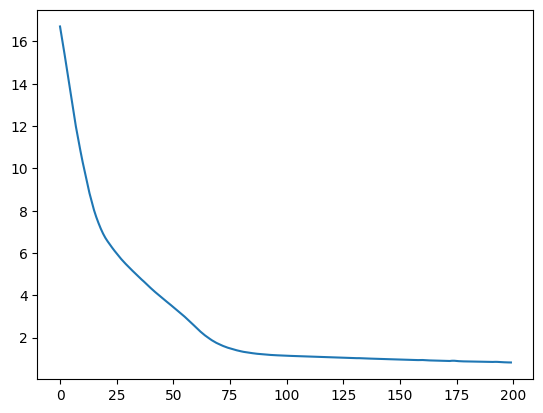

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

losses = model2.loss_curve_
iterations = range(model2.n_iter_)
sns.lineplot(x = iterations, y = losses)

__`Step 7`__ - Obtain the final loss of your model by calling the attribute __loss___


In [46]:
model2.loss_

0.8277954339473244

<a class="anchor" id="subsection-2-2">

### 2.2. Weight Matrices
</a>

__`Step 8`__ - Get the weight matrix by calling the attribute __coefs___


In [47]:
X_train.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

In [48]:
model2.coefs_

[array([[-0.14264482, -0.25995132],
        [ 0.04106504,  0.50679155],
        [-0.0964253 , -0.56767825],
        [-0.11102223, -0.02357159],
        [ 0.5678609 ,  0.51402009],
        [ 0.71552146,  0.35420803],
        [ 0.7629316 , -0.57911479],
        [ 0.06029267, -0.35467764]]),
 array([[-0.1466515 ],
        [ 0.15600104]])]

<img src="image1_nn.png" alt="Drawing" style="width: 500px;"/>

The diagram below shows the structure of a neural network with an input layer, one hidden layer with 2 neurons, and an output layer. The `coefs_` attribute contains the weight matrices that connect these layers.


__`Step 9`__ - Get the weights between the input and the hidden layer by calling the attribute __coefs_[0]__


In [49]:
model2.coefs_[0]

array([[-0.14264482, -0.25995132],
       [ 0.04106504,  0.50679155],
       [-0.0964253 , -0.56767825],
       [-0.11102223, -0.02357159],
       [ 0.5678609 ,  0.51402009],
       [ 0.71552146,  0.35420803],
       [ 0.7629316 , -0.57911479],
       [ 0.06029267, -0.35467764]])

__`Step 10`__ - Get the weights between the hidden layer and the output by calling the attribute __coefs_[1]__


In [50]:
model2.coefs_[1]

array([[-0.1466515 ],
       [ 0.15600104]])

__`Step 11`__ - Get the bias vector by calling the attribute __intercepts___


In [51]:
model2.intercepts_

[array([ 0.10368336, -0.02532763]), array([-0.62165134])]

<div class="alert alert-block alert-info">
<a class="anchor" id="third-bullet">     

# 3. Some Parameters in Neural Networks
</a>    
</div>

[Back to TOC](#toc)


### Understanding Activation Functions

Activation functions introduce non-linearity into neural networks, allowing them to learn complex patterns. Without activation functions, a neural network would simply be a linear model, regardless of how many layers it has.

**Common Activation Functions:**

1. **ReLU (Rectified Linear Unit)** - Default in MLPClassifier
   - Formula: $f(x) = max(0, x)$
   - Pros: Computationally efficient, helps avoid vanishing gradient problem
   - Cons: Can suffer from "dying ReLU" problem

2. **Sigmoid (Logistic)**
   - Formula: $f(x) = \frac{1}{1 + e^{-x}}$
   - Output range: (0, 1)
   - Often used in output layer for binary classification

3. **Tanh (Hyperbolic Tangent)**
   - Formula: $f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$
   - Output range: (-1, 1)
   - Zero-centered, which can help in learning

4. **Identity (Linear)**
   - Formula: $f(x) = x$
   - Used in regression problems (output layer)


In [52]:
def avg_score(model):
    # apply kfold
    skf = StratifiedKFold(n_splits=10)
    # create lists to store the results from the different models 
    score_train = []
    score_val = []
    timer = []
    n_iter = []
    
    for train_index, val_index in skf.split(X,y):
        # get the indexes of the observations assigned for each partition
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]
        # start counting time
        begin = time.perf_counter()
        # fit the model to the data
        model.fit(X_train, y_train)
        # finish counting time
        end = time.perf_counter()
        # check the mean accuracy for the train
        value_train = model.score(X_train, y_train)
        # check the mean accuracy for the validation
        value_val = model.score(X_val,y_val)
        # append the accuracies, the time and the number of iterations in the corresponding list
        score_train.append(value_train)
        score_val.append(value_val)
        timer.append(end-begin)
        n_iter.append(model.n_iter_)
    # calculate the average and the std for each measure (accuracy, time and number of iterations)
    avg_time = round(np.mean(timer),3)
    avg_train = round(np.mean(score_train),3)
    avg_val = round(np.mean(score_val),3)
    std_time = round(np.std(timer),2)
    std_train = round(np.std(score_train),2)
    std_val = round(np.std(score_val),2)
    avg_iter = round(np.mean(n_iter),1)
    std_iter = round(np.std(n_iter),1)
    
    return str(avg_time) + '+/-' + str(std_time), str(avg_train) + '+/-' + str(std_train),\
str(avg_val) + '+/-' + str(std_val), str(avg_iter) + '+/-' + str(std_iter)

def show_results(df, *args):
    """
    Receive an empty dataframe and the different models and call the function avg_score
    """
    count = 0
    # for each model passed as argument
    for arg in args:
        # obtain the results provided by avg_score
        time, avg_train, avg_val, avg_iter = avg_score(arg)
        # store the results in the right row
        df.iloc[count] = time, avg_train, avg_val, avg_iter
        count+=1
    return df

The following helper functions will allow us to compare different neural network configurations using cross-validation. The `avg_score` function performs Stratified K-Fold cross-validation and tracks:
- Training and validation accuracy
- Time taken to train
- Number of iterations until convergence

The `show_results` function organizes these metrics into a readable DataFrame for easy comparison.


<a class="anchor" id="subsection-3-1">

### 3.1. The Hidden Layer
</a>


__The number of hidden layers__<br>
-	Increase the number of hidden layers might improve the accuracy or might not, it depend on the complexity of the problem
-	Increase the number of hidden layers more than the sufficient ones will cause overfit on training set and the decrease of the accuracy in the validation set

__The number of hidden units__ <br>
-	Using too few neurons in hidden layers will result in underfitting
-	Using too many neurons in the hidden layer may result in overfitting and increase the time it takes to train the neural network

The aim is to keep a good trade-off between the simplicity of the model and the performance accuracy! <br>

__Some rule of thumbs:__
-	The number of hidden neurons should be between the size of the input layer and the size of the output layer
-	The number of hidden neurons should be 2/3 the size of the input layer, plus the size of the output layer
-	The number of hidden neurons should be less than twice the size of the input layer


__`Step 12`__ - Create an MLPClassifier with one hidden layer and one neuron and name it __model_simple__


In [53]:
model_simple = MLPClassifier(hidden_layer_sizes=(1))

__`Step 13`__ - Create an MLPClassifier with one hidden layer and 8 neurons and name it __model_medium__


In [54]:
model_medium = MLPClassifier(hidden_layer_sizes=(8))

__`Step 14`__ - Create an MLPClassifier with four hidden layers and 100 neurons each and name it __model_complex__


In [55]:
model_complex = MLPClassifier(hidden_layer_sizes=(100,100,100,100))

__`Step 15`__ - Check the mean accuracy of each model by calling the function _show_results_ and pass as arguments the dataset and the three models.


In [56]:
df = pd.DataFrame(columns = ['Time','Train','Validation', 'Iterations'], index = ['Simple','Medium','Complex'])
show_results(df, model_simple, model_medium, model_complex)

,Time,Train,Validation,Iterations
Simple,0.051+/-0.02,0.53+/-0.15,0.534+/-0.15,153.3+/-72.8
Medium,0.071+/-0.0,0.68+/-0.02,0.686+/-0.04,200.0+/-0.0
Complex,0.514+/-0.11,0.807+/-0.03,0.706+/-0.05,109.3+/-22.3


<div class="alert alert-block alert-success">
    
#### __Conclusion:__ <br>
- The more complex the model, the higher the running time;
- We can have a boost on the performance on our model when we adjust correctly the complexity of it - too simple leads to underfitting, and too complex can lead to overfitting.


<a class="anchor" id="subsection-3-2">

### 3.2. The Maximum Iterations
</a>


By default, sklearn defines the maximum number of iterations as 200. While this could be enough for simple datasets, in complex problems you should try higher values that allow the model to converge.

**What happens during iterations:**
- Each iteration represents one pass through the training data
- The model updates its weights to minimize the loss function
- More iterations allow the model to learn more complex patterns
- Too few iterations may result in underfitting (model hasn't learned enough)
- The number of iterations needed depends on 2 factors: data complexity and learning rate


__`Step 16`__ - Create an instance of MLPClassifier, define the max_iter as __20__, the __hidden_layer_sizes=(8)__ and name it as __model_maxiter_20__


In [57]:
model_maxiter_20 = MLPClassifier(max_iter = 20, hidden_layer_sizes=(8))

__`Step 17`__ - Create an instance of MLPClassifier, define the max_iter as __200__, the __hidden_layer_sizes=(8)__ and name it as __model_maxiter_200__


In [58]:
model_maxiter_200 = MLPClassifier(max_iter = 200, hidden_layer_sizes=(8))

__`Step 18`__ - Create an instance of MLPClassifier, define the max_iter as __1000__, the __hidden_layer_sizes=(8)__ and name it as __model_maxiter_1000__


In [59]:
model_maxiter_1000 = MLPClassifier(max_iter = 1000, hidden_layer_sizes=(8))

__`Step 19`__ - Check the mean accuracy of each model by calling the function _show_results_ and pass as arguments the dataset and the three models.


In [60]:
df = pd.DataFrame(columns = ['Time','Train','Validation', 'Iterations'], index = ['max iter 20','max iter 200','max iter 1000'])
show_results(df, model_maxiter_20, model_maxiter_200, model_maxiter_1000)

,Time,Train,Validation,Iterations
max iter 20,0.008+/-0.0,0.575+/-0.06,0.591+/-0.07,19.8+/-0.6
max iter 200,0.072+/-0.0,0.686+/-0.02,0.676+/-0.03,199.6+/-1.2
max iter 1000,0.167+/-0.05,0.72+/-0.02,0.712+/-0.03,477.0+/-149.0


<div class="alert alert-block alert-success">
    
#### __Conclusion:__ <br>
- Setting max_iter too low may prevent the model from converging, resulting in poor performance
- Increasing max_iter allows the model to continue learning until convergence
- Monitor the loss curve to determine if you need more iterations
- If the model hasn't converged, sklearn will issue a ConvergenceWarning


<div class="alert alert-block alert-info">
<a class="anchor" id="fourth-bullet">     

# 4. Comparing LR, DT and NN
</a>    
</div>

[Back to TOC](#toc)


Text(0.5, 1.0, "MLP's validation accuracy (with outliers): 93.33%")

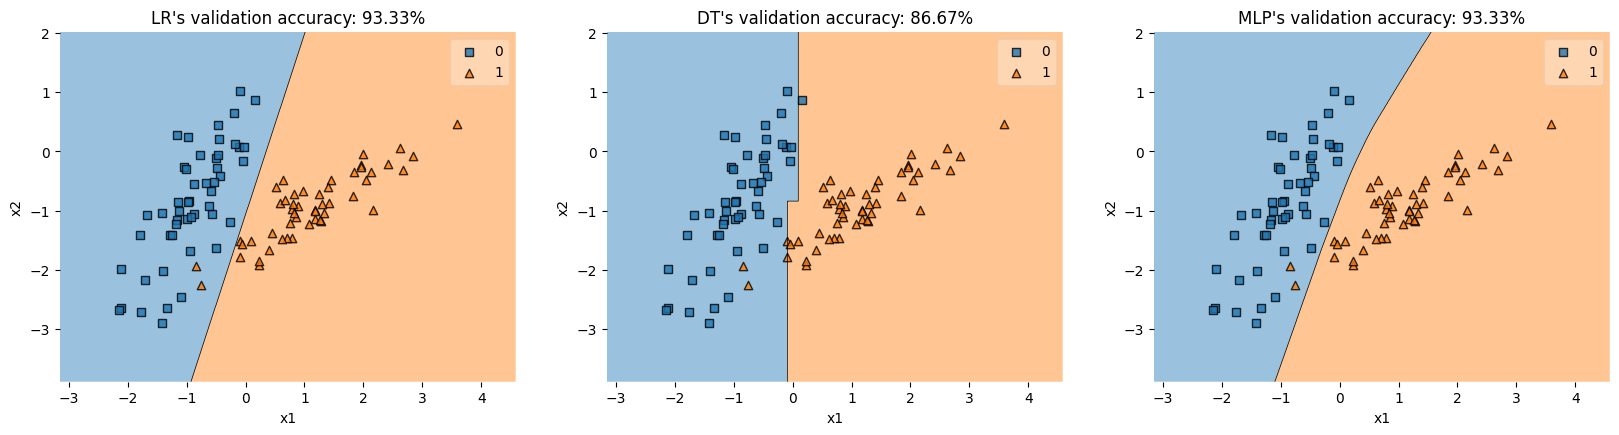

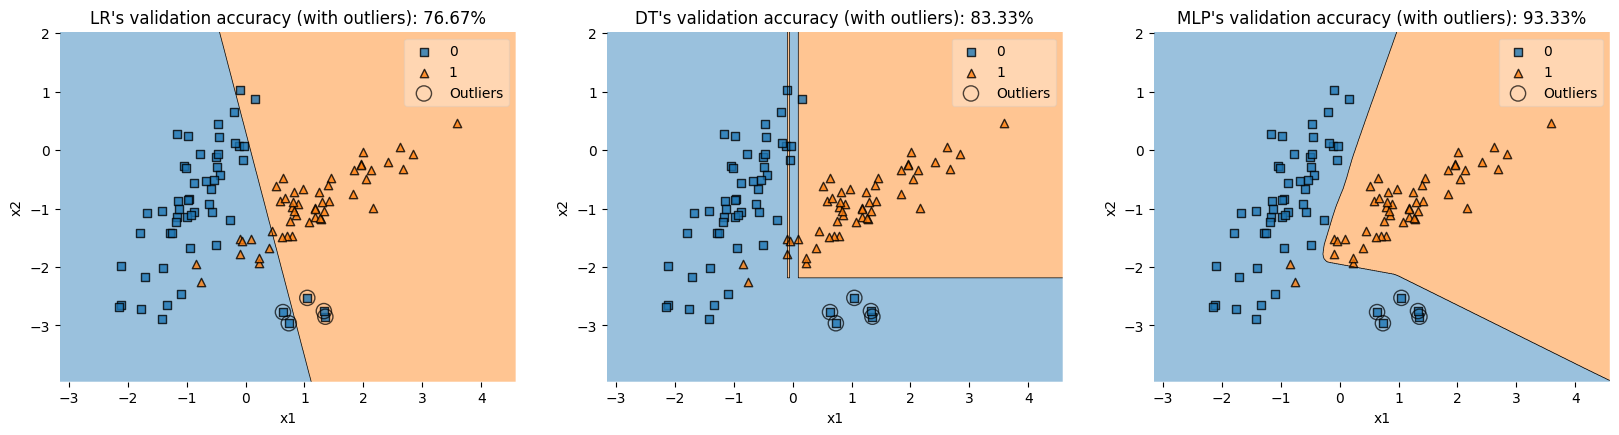

In [61]:
#!pip install mlxtend
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# 1) generate data for make_classification problem
X, y = make_classification(n_features=2, n_redundant=0, random_state=5, n_informative=2, n_clusters_per_class=1)

# 2) artificially introduce 5 outliers
n_out = 5
X_out = np.vstack((np.random.uniform(0.5, 1.5, n_out), np.random.uniform(-3, -2.5, n_out))).transpose()
y_out = np.zeros(X_out.shape[0])

# 3) split the data into training and unseen (validation)
X_training, X_unseen, y_training, y_unseen = train_test_split(X, y, train_size=0.7, random_state=5)
# create an object named as X_train_out that will contain the ouliers
X_train_out = np.vstack((X_training, X_out))
# create an object named y_train_out that will contain the observations with outliers
y_train_out = np.concatenate((y_training, y_out)).astype(int)

# 4) estimate models without outliers 
# 4) 1) instantiate and train a Logistic Regression model
lr = LogisticRegression(random_state=5)
lr.fit(X_training, y_training)
# 4) 2) instantiate and train a Decision Tree model
dt = DecisionTreeClassifier(random_state=5)
dt.fit(X_training, y_training)
# 4) 3) instantiate and train a MLP model
mlp = MLPClassifier(random_state=5, max_iter = 1000)
mlp.fit(X_training, y_training)

# 5) estimate models with outliers 
# 5) 1) instantiate and train a Logistic Regression model
lr_out = LogisticRegression(random_state=5)
lr_out.fit(X_train_out, y_train_out)
# 5) 2) instantiate and train a Decision Tree model
dt_out = DecisionTreeClassifier(random_state=5)
dt_out.fit(X_train_out, y_train_out)
# 5) 3) instantiate and train a MLP model
mlp_out = MLPClassifier(random_state=5, max_iter = 1000)
mlp_out.fit(X_train_out, y_train_out)

# 6) plot classification boundaries
plt.figure(figsize=(20,10))

# 6) 1) LR without outliers
plt.subplot(231)
plot_decision_regions(X=X, y=y, clf=lr)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("LR's validation accuracy: {0:.2f}%".format(100*(lr.score(X_unseen, y_unseen))))

# 6) 2) DT without outliers
plt.subplot(232)
plot_decision_regions(X=X, y=y, clf=dt)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("DT's validation accuracy: {0:.2f}%".format(100*(dt.score(X_unseen, y_unseen))))

# 6) 3) MLP without outliers
plt.subplot(233)
plot_decision_regions(X=X, y=y, clf=mlp)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("MLP's validation accuracy: {0:.2f}%".format(100*(mlp.score(X_unseen, y_unseen))))

# 6) plot classification boundaries
X = np.vstack((X, X_out))
y = np.concatenate((y, y_out)).astype(int)
plt.figure(figsize=(20,10))

# 6) 4) LR with outliers
plt.subplot(234)
plot_decision_regions(X=X, y=y, clf=lr_out, X_highlight=X_out,
                          scatter_highlight_kwargs = {'s': 120, 'label': 'Outliers', 'alpha': 0.7})
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("LR's validation accuracy (with outliers): {0:.2f}%".format(100*(lr_out.score(X_unseen, y_unseen))))

# 6) 5) DT with outliers
plt.subplot(235)
plot_decision_regions(X=X, y=y, clf=dt_out, X_highlight=X_out,
                          scatter_highlight_kwargs = {'s': 120, 'label': 'Outliers', 'alpha': 0.7})
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("DT's validation accuracy (with outliers): {0:.2f}%".format(100*(dt_out.score(X_unseen, y_unseen))))

# 6) 5) MLP with outliers
plt.subplot(236)
plot_decision_regions(X=X, y=y, clf=mlp_out, X_highlight=X_out,
                          scatter_highlight_kwargs = {'s': 120, 'label': 'Outliers', 'alpha': 0.7})
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("MLP's validation accuracy (with outliers): {0:.2f}%".format(100*(mlp_out.score(X_unseen, y_unseen))))

In this section, we will compare the decision boundaries created by Logistic Regression, Decision Trees, and Neural Networks. We will also see how each algorithm handles outliers differently. Neural networks tend to create smoother, more flexible decision boundaries compared to the linear boundaries of logistic regression or the rectangular boundaries of decision trees.


<div class="alert alert-block alert-info">
<a class="anchor" id="fifth-bullet">     

# 5. The Importance of Scaling (EXERCISE)
</a>    
</div>

[Back to TOC](#toc)


In most cases, your dataset will contain features that differ significantly in terms of magnitudes, units and range. Due to the fact that the majority of machine learning algorithms use Euclidean distance between two data points in their computations, this can be a problem.<br><br>

If left on the original format, those algorithms will consider significantly the magnitude of features and this could lead to biased results. <br><br>
As an example, if we consider a variable as weight, the algorithm will work differently if that feature is measured in kilograms or in grams - having a value of 5000 grams will give more "weight" to the feature than having a value of 5 kilograms. <br>The features with high magnitudes will weigh in a lot more in the distance calculations than features with low magnitudes. To suppress this effect, we need to bring all features to the same level of magnitudes.

It is a good practice to normalize the data by putting its mean to zero and its variance to one, or to rescale it by fixing the minimum and the maximum between -1 and 1 or 0 and +1. <br>

<a class="anchor" id="subsection-5-1">

### 5.1. MinMax Scaler
</a>

__`Step 20`__ - Import __MinMaxScaler__ from __sklearn.preprocessing__


In [62]:
from sklearn.preprocessing import MinMaxScaler

<div class="alert alert-block alert-info">
<a href='https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html'>sklearn.preprocessing.MinMaxScaler(feature_range=(0, 1), ...)</a>

**Definition:**  
Transform features by scaling each feature to a given range.

**Main Parameters:**  
- `feature_range`: Desired range of transformed data (default=(0, 1))

**Main Methods:**  
- `fit(X)`: Compute the minimum and maximum to be used for later scaling
- `transform(X)`: Scale features of X according to feature_range
- `fit_transform(X)`: Fit to data, then transform it
- `inverse_transform(X)`: Undo the scaling of X according to feature_range
</div>


MinMaxScaler is the simplest method and consists in rescaling the range of features to scale in range in [0,1] or [-1,1]. The general formula is:

$$x^{'} = \frac{x - min(x)}{max(x) - min(x)}$$

where $x$ is the original value and $x^{'}$ is the normalized one. <br>
To rescale between a tuple of values [a,b], the formula becomes: <br>

$$x^{'} = a + \frac{(x - min(x))(b-a)}{max(x) - min(x)}$$

where $a$ is the minimum value and $b$ the maximum value.

`When to use` 
- Use this as the first scaler choice to transform a feature, as it will preserve the shape of the dataset (no distortion);
- Least disruptive to the information in the original data.

`Note`
- Doesn't reduce the importance of outliers.

#### 5.1.1. Rescale between [0,1]

__`Step 21`__ - Create an object named __min_max1__ that will contain an instance of __MinMaxScaler()__ fitted to your __X_train__


__`Step 21`__ Create an object named __min_max1__ that will contain an instance of __MinMaxScaler()__ fitted to your __X_train__

In [63]:
min_max1 = MinMaxScaler().fit(X_train)

__`Step 22`__ - Create an object named __min_max1_X_train__ that will contain the __X_train__ scaled, by calling the method __transform()__ to your fitted instance created in the previous step.


In [64]:
min_max1_X_train = min_max1.transform(X_train)

__`Step 23`__ - Similarly to Step 22, create an object named as __min_max1_X_val__ that will transform your __X_val__


In [65]:
min_max1_X_val = min_max1.transform(X_val)

__`Step 24`__ - Create an object named __model_min_max1__ that will contain a MLPClassifier model fitted to your scaled training data.


In [66]:
model_min_max1 = MLPClassifier().fit(min_max1_X_train, y_train)

__`Step 25`__ - Calculate the mean accuracy of your classifier in your __min_max1_X_val__ and __y_val__ by calling the method __score()__ and define it as __score_minmax1__


In [67]:
model_min_max1.score(min_max1_X_val, y_val)

0.7532467532467533

#### 5.1.2. Rescale between [-1,1]

__`Step 26`__ - Similarly to the steps included in the _**topic 5.1.1.**_, this time apply MinMaxScaler(), but define the parameter __feature_range = (-1,1)__. Check the mean accuracy of your new classifier.


In [68]:
# Create a MinMaxScaler instance that will range between -1 and 1 and fit to your train data
min_max2 = MinMaxScaler(feature_range=(-1,1)).fit(X_train)
# Transform your train data by applying the scale obtained in the previous command
min_max2_X_train = min_max2.transform(X_train)
# Transform your validation data by applying the scale obtained in the first command
min_max2_X_val = min_max2.transform(X_val)
# Create a new classifier and fit to your scaled training data
model_min_max2 = MLPClassifier().fit(min_max2_X_train, y_train)
# Check the mean accuracy of your classifier in your validation data
model_min_max2.score(min_max2_X_val, y_val)

0.7922077922077922

<a class="anchor" id="subsection-5-2">

### 5.2. Standard Scaler
</a>

__`Step 27`__ - Import __StandardScaler__ from __sklearn.preprocessing__


In [69]:
from sklearn.preprocessing import StandardScaler

<div class="alert alert-block alert-info">
<a href='https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html'>sklearn.preprocessing.StandardScaler(with_mean=True, with_std=True, ...)</a>

**Definition:**  
Standardize features by removing the mean and scaling to unit variance.

**Main Parameters:**  
- `with_mean`: If True, center the data before scaling (default=True)
- `with_std`: If True, scale the data to unit variance (default=True)

**Main Methods:**  
- `fit(X)`: Compute the mean and std to be used for later scaling
- `transform(X)`: Perform standardization by centering and scaling
- `fit_transform(X)`: Fit to data, then transform it
- `inverse_transform(X)`: Scale back the data to the original representation
</div>


StandardScaler applies standardization to data. <br>
It standardizes a feature by removing the mean and dividing each value by the standard deviation. The formula is:


$$x^{'} = \frac{x - \bar{x}}{\sigma }$$

where $x^{'}$ is the standardized value, $x$ is the original feature, $\bar{x}$ is the average of $x$ and $\sigma$ is its standard deviation.

`When to use` 
- Use it if you know the data distribution is normal;

`Note`
- If you have outliers in your variable, applying StandardScaler will scale most of the data to a small interval;

__`Step 28`__ - Create an object named __scaler__ that will contain an instance of __StandardScaler()__ fitted to your __X_train__


In [70]:
scaler = StandardScaler().fit(X_train)

__`Step 29`__ - Transform your training dataset using the scaler and define it as a new object named __scaler_X_train__. Do the same for your validation data, and name the new object as __scaler_X_val__


In [71]:
scaler_X_train = scaler.transform(X_train)
scaler_X_val = scaler.transform(X_val)

__`Step 30`__ - Create a MLPClassifier named __model_scaler__ and fit to your scaled training data.


In [72]:
model_scaler = MLPClassifier().fit(scaler_X_train, y_train)

__`Step 31`__ - Check the mean accuracy of your previous model in your validation data by calling the method __score()__


In [73]:
model_scaler.score(scaler_X_val, y_val)

0.7792207792207793

<a class="anchor" id="subsection-5-3">

### 5.3. Robust Scaler
</a>

__`Step 32`__ - Import __RobustScaler__ from __sklearn.preprocessing__


In [74]:
from sklearn.preprocessing import RobustScaler

<div class="alert alert-block alert-info">
<a href='https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html'>sklearn.preprocessing.RobustScaler(with_centering=True, with_scaling=True, quantile_range=(25.0, 75.0), ...)</a>

**Definition:**  
Scale features using statistics that are robust to outliers.

**Main Parameters:**  
- `with_centering`: If True, center the data before scaling (default=True)
- `with_scaling`: If True, scale the data to interquartile range (default=True)
- `quantile_range`: Quantile range used to calculate scale (default=(25.0, 75.0))

**Main Methods:**  
- `fit(X)`: Compute the median and quantiles to be used for scaling
- `transform(X)`: Center and scale the data
- `fit_transform(X)`: Fit to data, then transform it
- `inverse_transform(X)`: Scale back the data to the original representation
</div>


The RobustScaler scales the data according to the quantile range. <br>
It is an alternative for StandardScaler when in presence of outliers, because those influence the mean/variance in a negative way. <br>In those cases, the interquartile range often give better results. The formula is:


$$x^{'} = \frac{x - Q_{1}(x)}{Q_{3}(x) - Q_{1}(x)}$$

where $x^{'}$ is the scaled value, $x$ is the original feature, $Q_{1}(x)$ is the first quantile of the feature and  $Q_{3}(x)$ is the third quantile.

`When to use` 
- Use if you have outliers and don't want them to have much influence (but removing outliers is always a better option);
- Outliers have less influence than in other methods. The range is larger than MinMaxScaler or StandardScaler.

__`Step 33`__ - Similarly to what was done in the previous scalers, apply this time the RobustScaler and check the mean accuracy of a model fitted to your new scaled data.


In [75]:
# Create a RobustScaler instanceand fit to your train data
robust = RobustScaler().fit(X_train)
# Transform your train data by applying the scale obtained in the previous command
robust_X_train = robust.transform(X_train)
# Transform your validation data by applying the scale obtained in the first command
robust_X_val = robust.transform(X_val)
# Create a new classifier and fit to your scaled training data
model_robust = MLPClassifier().fit(robust_X_train, y_train)
# Check the mean accuracy of your classifier in your validation data
model_robust.score(robust_X_val, y_val)

0.7662337662337663

__`Step 34`__ - Plot the different results using a barplot.


<Axes: >

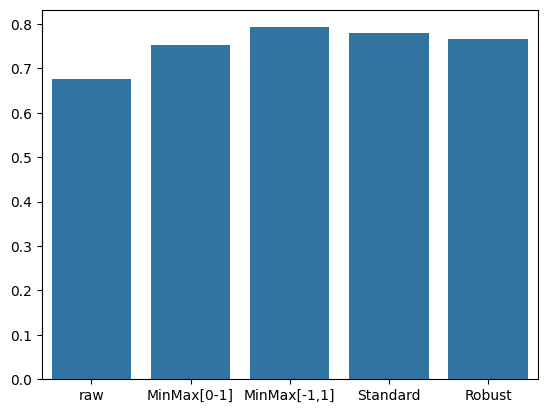

In [76]:
x = ['raw','MinMax[0-1]','MinMax[-1,1]','Standard','Robust']
y = [model.score(X_val, y_val), model_min_max1.score(min_max1_X_val, y_val), 
    model_min_max2.score(min_max2_X_val, y_val),model_scaler.score(scaler_X_val, y_val),
    model_robust.score(robust_X_val, y_val)]
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x = x, y = y)

<div class="alert alert-block alert-success">
    
#### __Conclusion:__ <br>
Feature scaling is critical for neural networks:
- Neural networks use gradient-based optimization that is sensitive to the scale of features
- Without scaling, features with larger magnitudes dominate the learning process
- Properly scaled features lead to faster convergence and better model performance
- Choose the scaler based on your data distribution and the presence of outliers
